In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from lightgbm import LGBMClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/all tte.csv')


In [ ]:
df1

In [ ]:
feature= df1.drop(['CLASS-LABEL'], axis=1)
labels = df1['CLASS-LABEL']


In [ ]:

labels

,CLASS-LABEL
0,0
1,0
2,0
3,0
4,0
...,...
49036,3
49037,3
49038,3
49039,3


**Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
feature = feature.apply(le.fit_transform)


In [ ]:
#feature.replace([np.inf, -np.inf],np.nan,inplace=True)
#feature=np.nan_to_num( feature)
#labels=np.nan_to_num( labels)


**SMOTE SAMPLING**

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE()

feature_res, labels_res = smote.fit_resample(feature, labels)



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(feature)

**Standard Scaler For Features Scaling**

In [ ]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 97.42%

Confusion Matrix:
 [[33431     1     0   409]
 [   30  2874     0    32]
 [    0     0   312     0]
 [  774    18     0 11160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     33841
           1       0.99      0.98      0.99      2936
           2       1.00      1.00      1.00       312
           3       0.96      0.93      0.95     11952

    accuracy                           0.97     49041
   macro avg       0.98      0.98      0.98     49041
weighted avg       0.97      0.97      0.97     49041


MCC ---> 0.9438


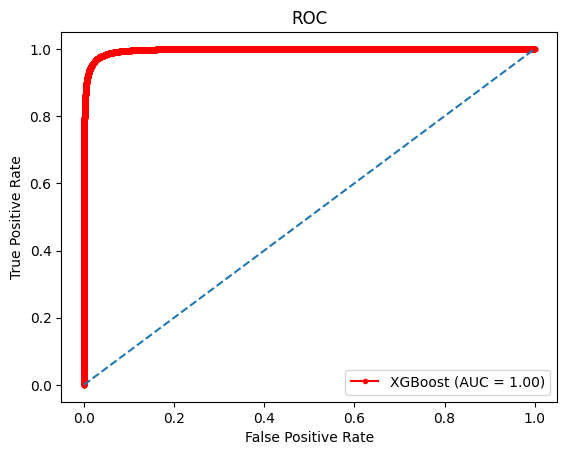

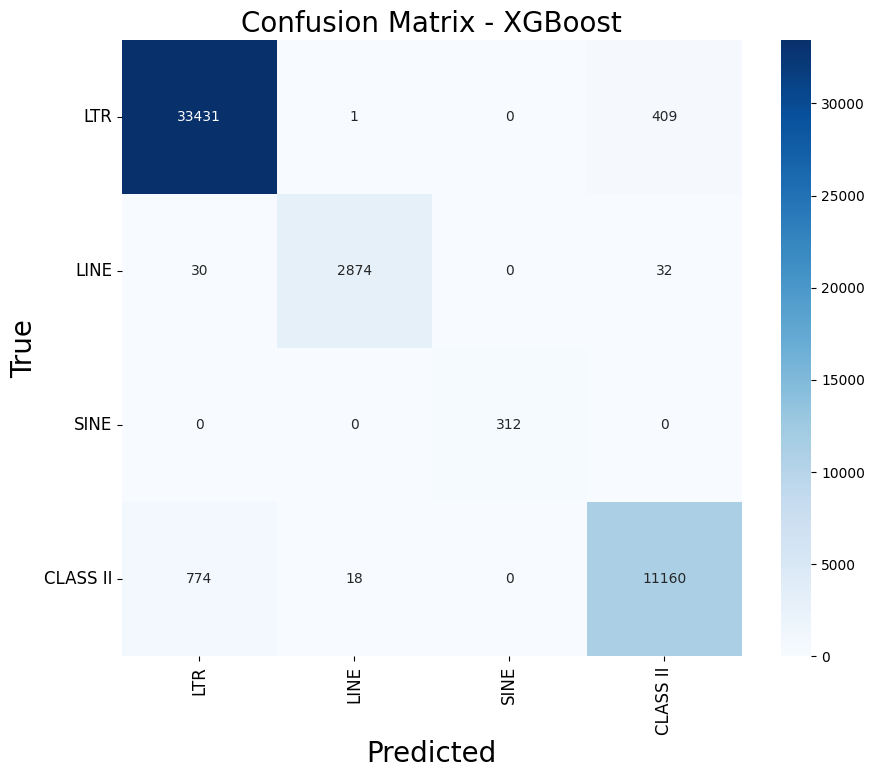

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 4

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.482461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127921
[LightGBM] [Info] Number of data points in the train set: 49041, number of used features: 516
[LightGBM] [Info] Start training from score -0.370984
[LightGBM] [Info] Start training from score -2.815609
[LightGBM] [Info] Start training from score -5.057409
[LightGBM] [Info] Start training from score -1.411758
Self-Consistency Accuracy: 93.21%

Confusion Matrix:
 [[32760    29     0  1052]
 [   92  2703     0   141]
 [    0     0   312     0]
 [ 1937    77     0  9938]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95     33841
           1       0.96      0.92      0.94      2936
           2       1.00      1.00      1.00       312
           3       0.89      0.83      0.86     11952

    accuracy                    

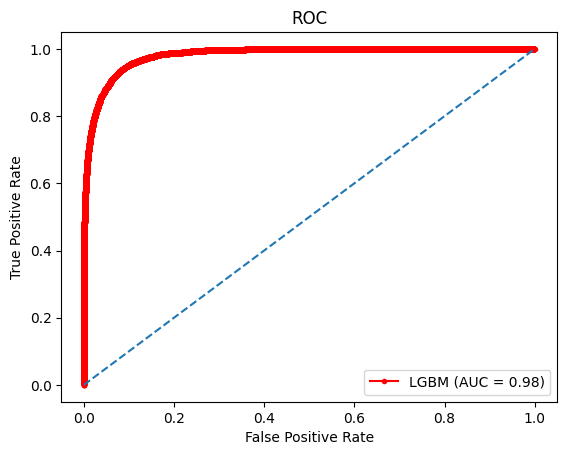

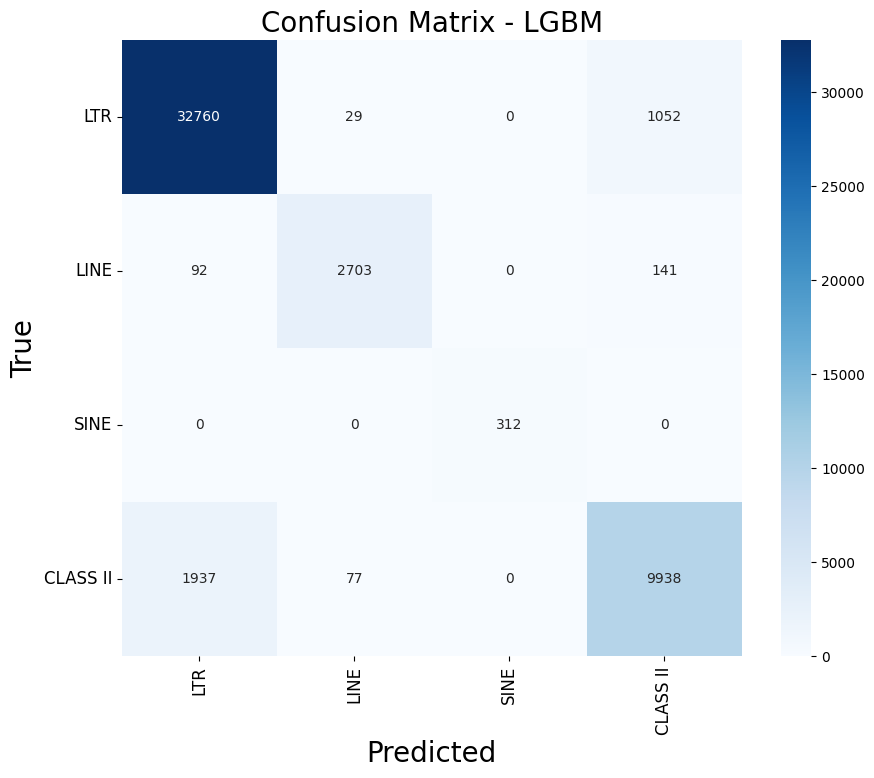

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)


# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 4

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.31%

Confusion Matrix:
 [[33815     0     1    25]
 [   71  2857     0     8]
 [    0     3   305     4]
 [  224     1     1 11726]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     33841
           1       1.00      0.97      0.99      2936
           2       0.99      0.98      0.99       312
           3       1.00      0.98      0.99     11952

    accuracy                           0.99     49041
   macro avg       1.00      0.98      0.99     49041
weighted avg       0.99      0.99      0.99     49041


MCC ---> 0.9850


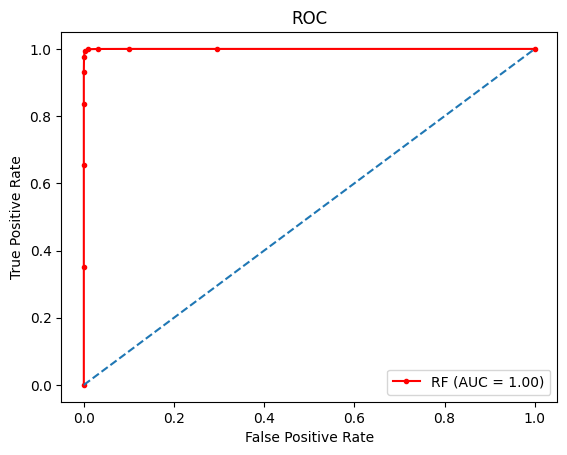

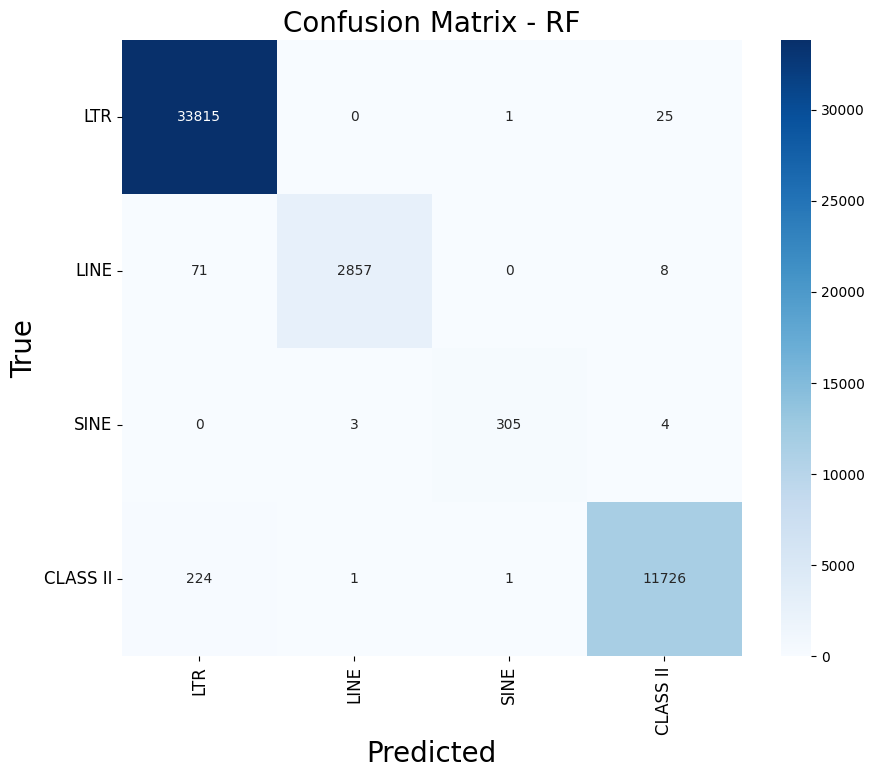

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 4

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 100.00%

Confusion Matrix:
 [[33841     0     0     0]
 [    0  2936     0     0]
 [    0     0   312     0]
 [    0     0     0 11952]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33841
           1       1.00      1.00      1.00      2936
           2       1.00      1.00      1.00       312
           3       1.00      1.00      1.00     11952

    accuracy                           1.00     49041
   macro avg       1.00      1.00      1.00     49041
weighted avg       1.00      1.00      1.00     49041


MCC ---> 1.0000


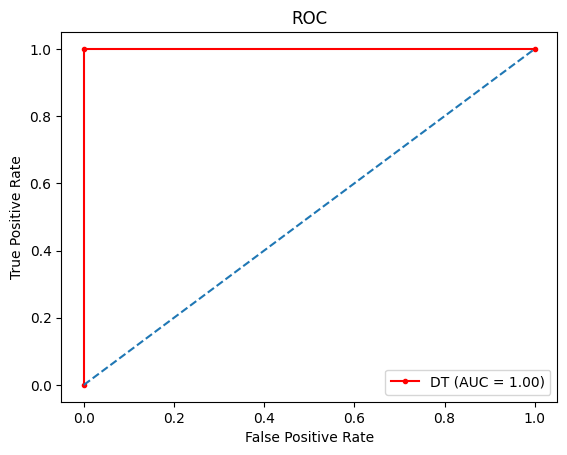

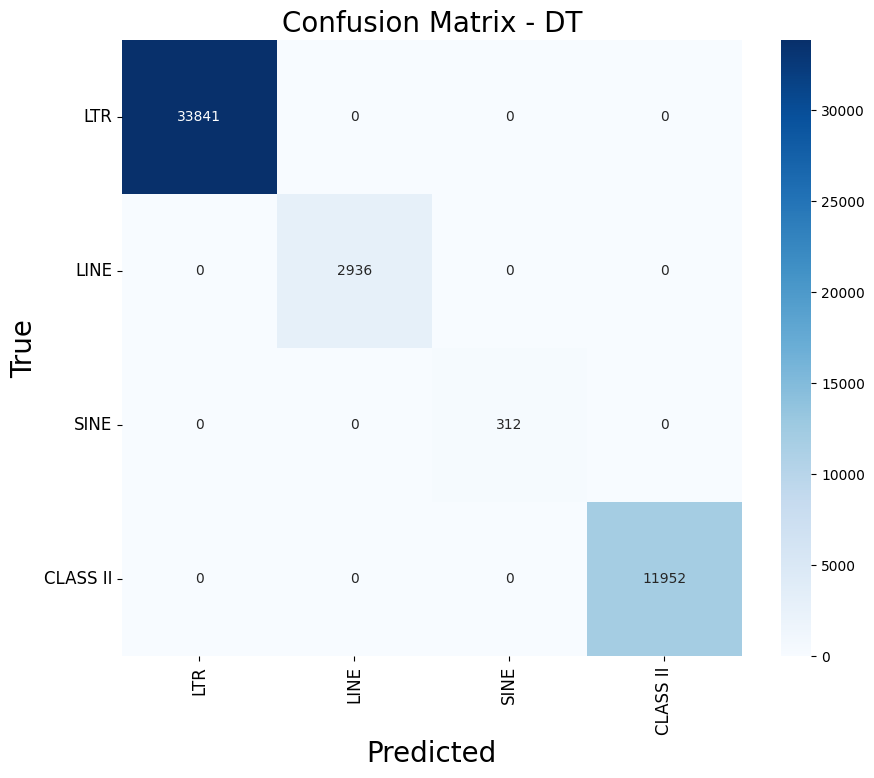

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 4

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


# **ROC-SELF TEST**

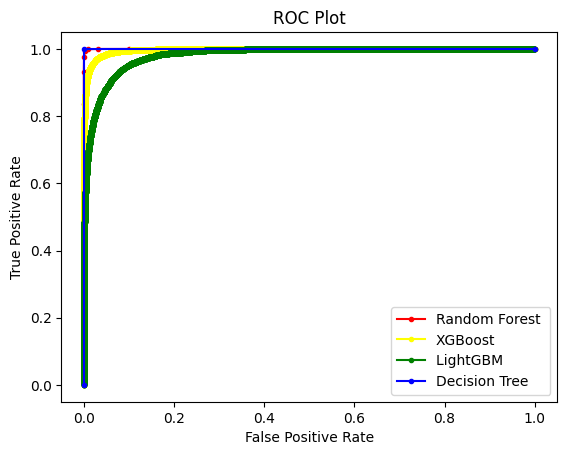

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


#  **Independent Set Testing (Train Test Split)**    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(feature_res , labels_res, test_size=0.3, random_state=100,stratify=labels_res)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(94754, 521) (40610, 521)
(94754,) (40610,)


Training accuracy is 0.986976803090107
Test accuracy is 0.9561684314208323
[[ 9166   110     0   877]
 [   22 10082     1    47]
 [    0     0 10152     0]
 [  541   166    16  9430]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     10153
           1       0.97      0.99      0.98     10152
           2       1.00      1.00      1.00     10152
           3       0.91      0.93      0.92     10153

    accuracy                           0.96     40610
   macro avg       0.96      0.96      0.96     40610
weighted avg       0.96      0.96      0.96     40610

Accuracy 95.62%
MCC ---> 0.9416580003131385
Sensitivity :  0.988141440275981
Specificity :  0.9978226444972288


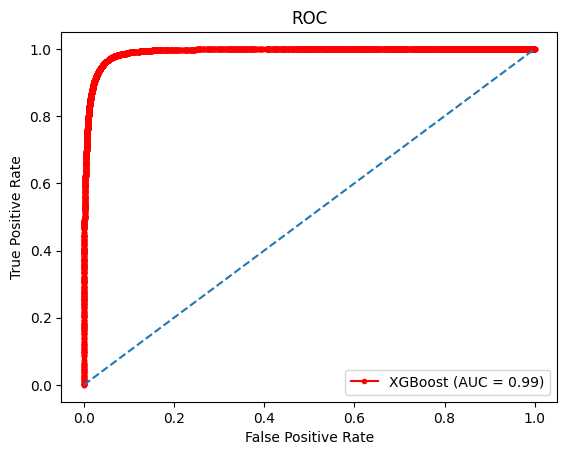

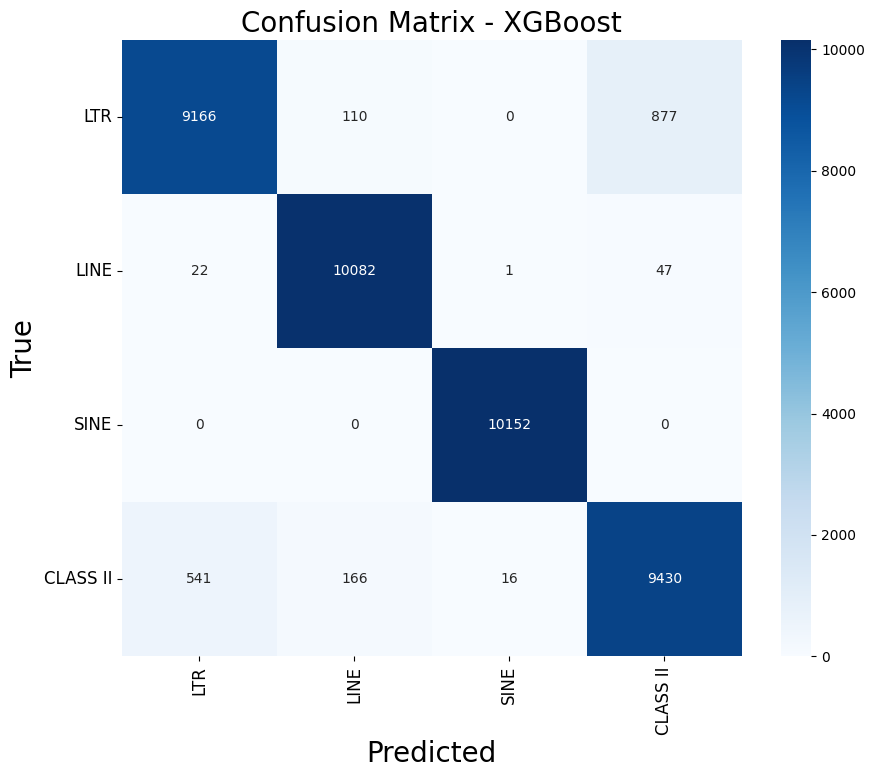

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 4

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels =['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9985119361715601
Test accuracy is 0.9492243289830091
[[ 9251   171     2   729]
 [   89 10023    13    27]
 [    2     5 10144     1]
 [  773   213    37  9130]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     10153
           1       0.96      0.99      0.97     10152
           2       0.99      1.00      1.00     10152
           3       0.92      0.90      0.91     10153

    accuracy                           0.95     40610
   macro avg       0.95      0.95      0.95     40610
weighted avg       0.95      0.95      0.95     40610

Accuracy 94.92%
MCC ---> 0.9323525433025869
Sensitivity :  0.9818509870515814
Specificity :  0.9911985759493671


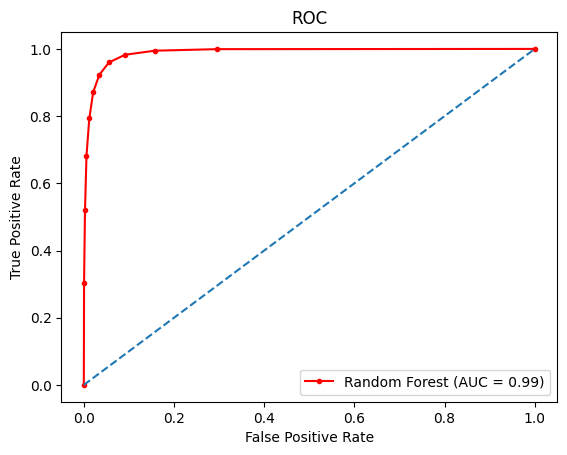

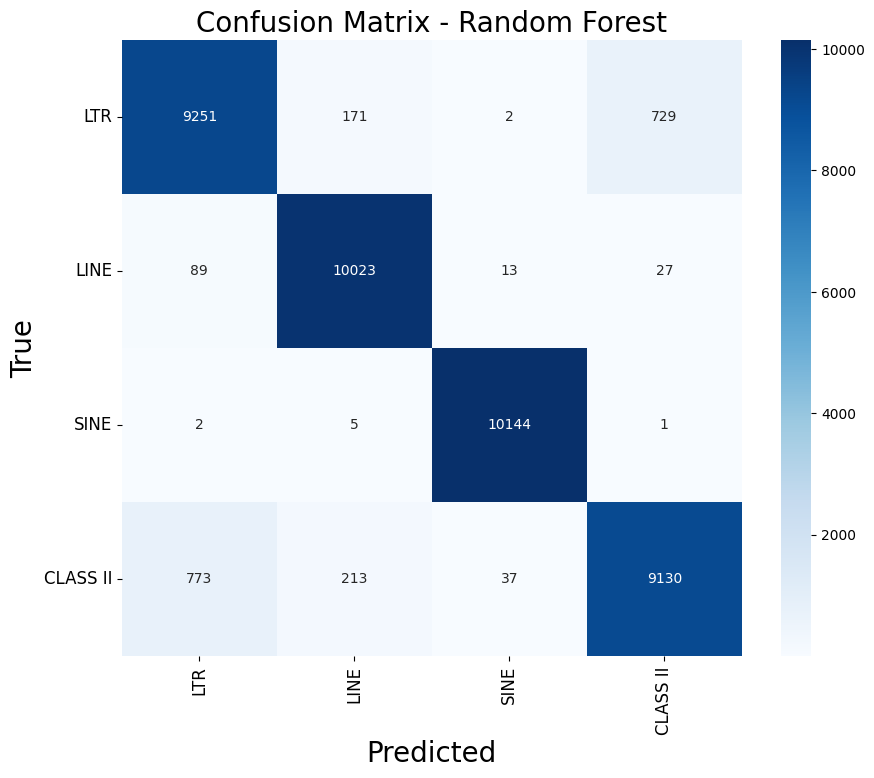

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 4
for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 1.0
Test accuracy is 0.9111548879586309
[[ 8586   336     6  1225]
 [  214  9579    74   285]
 [    5    28 10079    40]
 [  963   366    66  8758]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.86     10153
           1       0.93      0.94      0.94     10152
           2       0.99      0.99      0.99     10152
           3       0.85      0.86      0.86     10153

    accuracy                           0.91     40610
   macro avg       0.91      0.91      0.91     40610
weighted avg       0.91      0.91      0.91     40610

Accuracy 91.12%
MCC ---> 0.8816119466235414
Sensitivity :  0.9623402824478816
Specificity :  0.9781476564893291


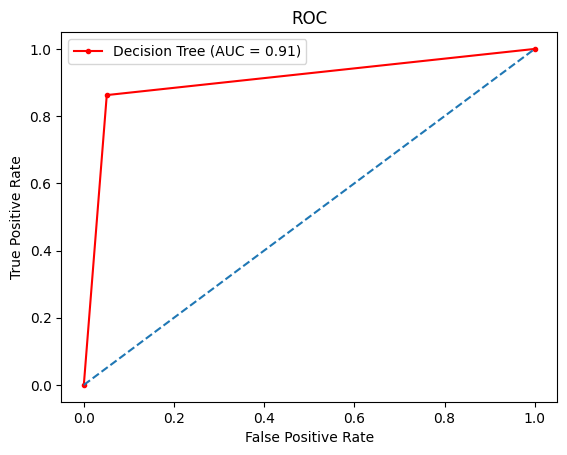

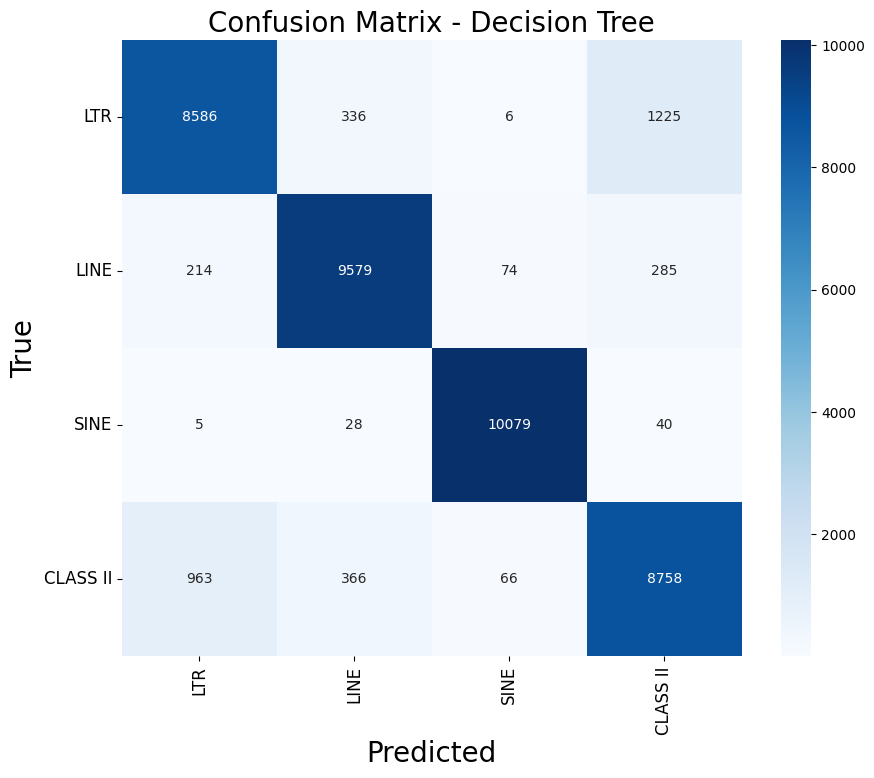

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 4

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.644820 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127547
[LightGBM] [Info] Number of data points in the train set: 94754, number of used features: 516
[LightGBM] [Info] Start training from score -1.386315
[LightGBM] [Info] Start training from score -1.386273
[LightGBM] [Info] Start training from score -1.386273
[LightGBM] [Info] Start training from score -1.386315


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training accuracy is 0.9610148384237077


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test accuracy is 0.9414676188131003


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[ 8966   126     0  1061]
 [   60  9979     9   104]
 [    0     0 10152     0]
 [  719   266    32  9136]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     10153
           1       0.96      0.98      0.97     10152
           2       1.00      1.00      1.00     10152
           3       0.89      0.90      0.89     10153

    accuracy                           0.94     40610
   macro avg       0.94      0.94      0.94     40610
weighted avg       0.94      0.94      0.94     40610

Accuracy 94.15%
MCC ---> 0.922045559286489
Sensitivity :  0.9861416630004399
Specificity :  0.9940233090945313


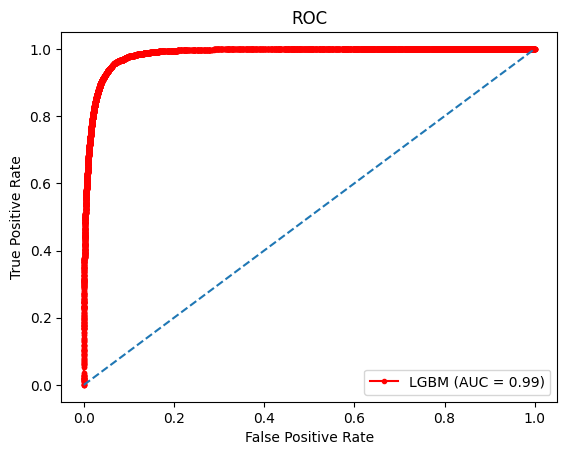

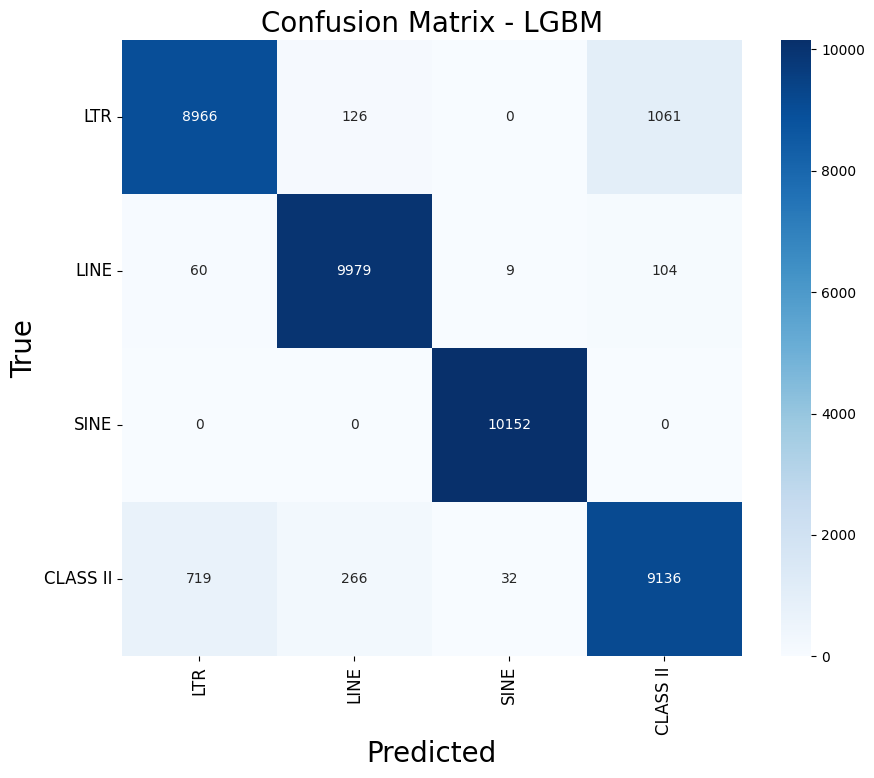

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 4

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

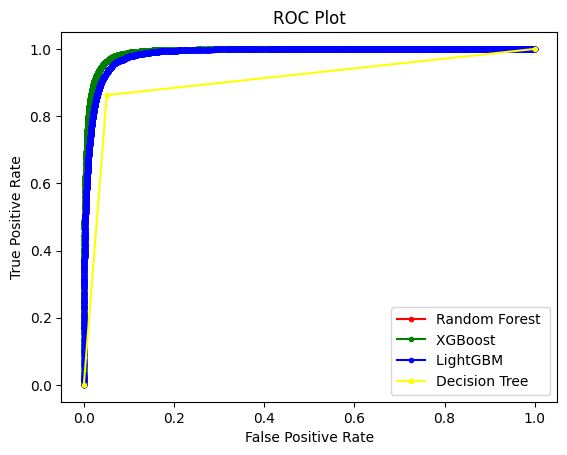

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Mean of Accuracies:  81.23823195361126
[[31798   332     2  1709]
 [  978  1432    50   476]
 [    6    71   123   112]
 [ 4919   459    87  6487]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     33841
           1       0.62      0.49      0.55      2936
           2       0.47      0.39      0.43       312
           3       0.74      0.54      0.63     11952

    accuracy                           0.81     49041
   macro avg       0.67      0.59      0.62     49041
weighted avg       0.80      0.81      0.80     49041

Accuracy 81.24%
MCC ---> 0.5665174332926679
Sensitivity :  0.989666977902272
Specificity :  0.5941908713692946


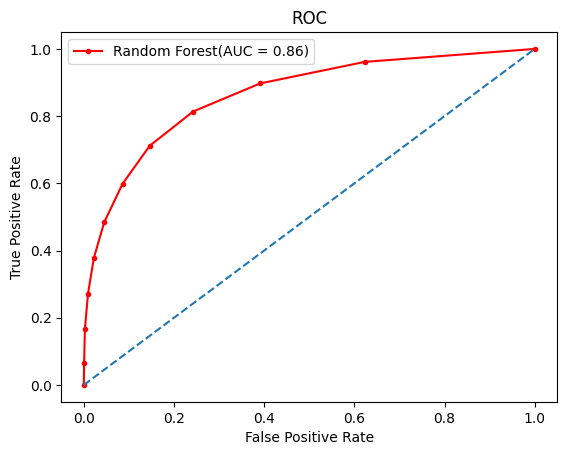

In [ ]:
rclf2 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf2.fit(feature,labels)
score_rclf2 = cross_val_score(rclf2, feature , labels, cv = 10)
res=score_rclf2.mean()
print('Mean of Accuracies: ',res*100,end='\n')
pred_prob =cross_val_predict(rclf2, feature , labels, cv = 10 ,method='predict_proba')
y_pred_test = cross_val_predict(rclf2, feature , labels, cv = 10)
cm_rf1=confusion_matrix(labels,y_pred_test)
print(cm_rf1)
cr_rf1=classification_report(labels,y_pred_test)
print(cr_rf1)
print("Accuracy {0:.2f}%".format(100*accuracy_score(labels, y_pred_test)))
# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))
sensitivity1 = cm_rf1[0,0]/(cm_rf1[0,0]+cm_rf1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm_rf1[1,1]/(cm_rf1[1,0]+cm_rf1[1,1])
print('Specificity : ', specificity1)



#AUC SCORE
fpr_rf2 = {}
tpr_rf2 = {}
thresh_rf2 ={}

n_class = 4

for i in range(n_class):
    fpr_rf2[i], tpr_rf2[i], thresh_rf2[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf2 = auc(fpr_rf2[i], tpr_rf2[i])
roc_rf2

import matplotlib.pyplot as plt
plt.title('ROC')
plt.plot(fpr_rf2[i], tpr_rf2[i], marker='.',color='red',label = 'Random Forest(AUC = %0.2f)' % roc_rf2)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#Show legend
plt.legend()
plt.savefig('cross-val-test-rf_roc.png')
# Show plot
plt.show()





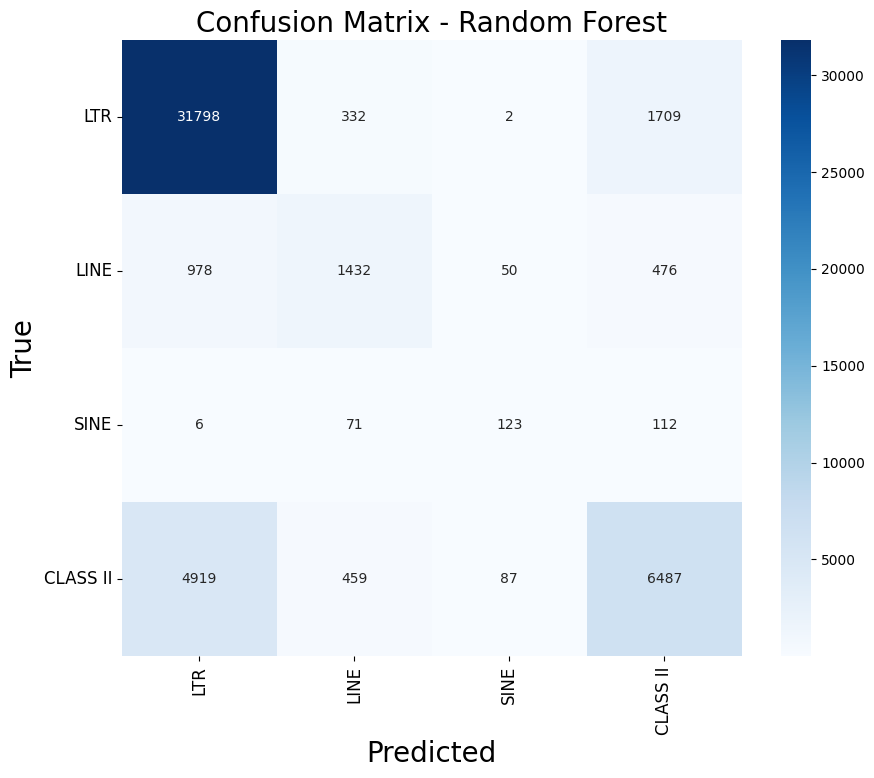

In [ ]:
### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf1=confusion_matrix(labels,y_pred_test)

## Get Class Labels
label  = ['LTR','LINE','SINE','CLASS II']
class_names = label

### Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_rf1, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show

plt.savefig('rf_cross-val-_cm.png')
plt.show()

Mean of Accuracies:  83.99509730557592
[[31455   310     0  2076]
 [  613  1926    25   372]
 [    3    43   165   101]
 [ 3905   349    52  7646]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     33841
           1       0.73      0.66      0.69      2936
           2       0.68      0.53      0.60       312
           3       0.75      0.64      0.69     11952

    accuracy                           0.84     49041
   macro avg       0.76      0.69      0.72     49041
weighted avg       0.83      0.84      0.84     49041

Accuracy 84.00%
MCC ---> 0.6393321218713013
Sensitivity :  0.9902408311034158
Specificity :  0.758566364710516


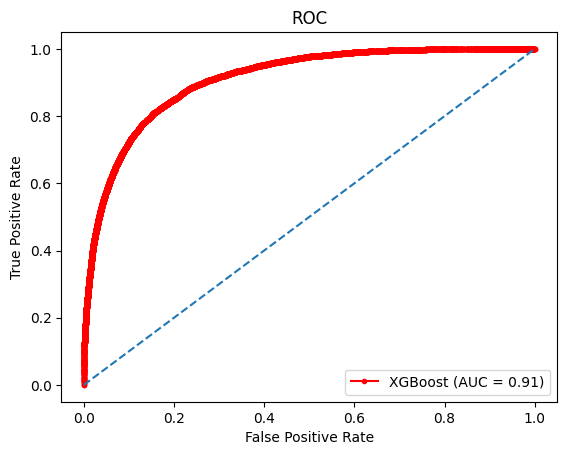

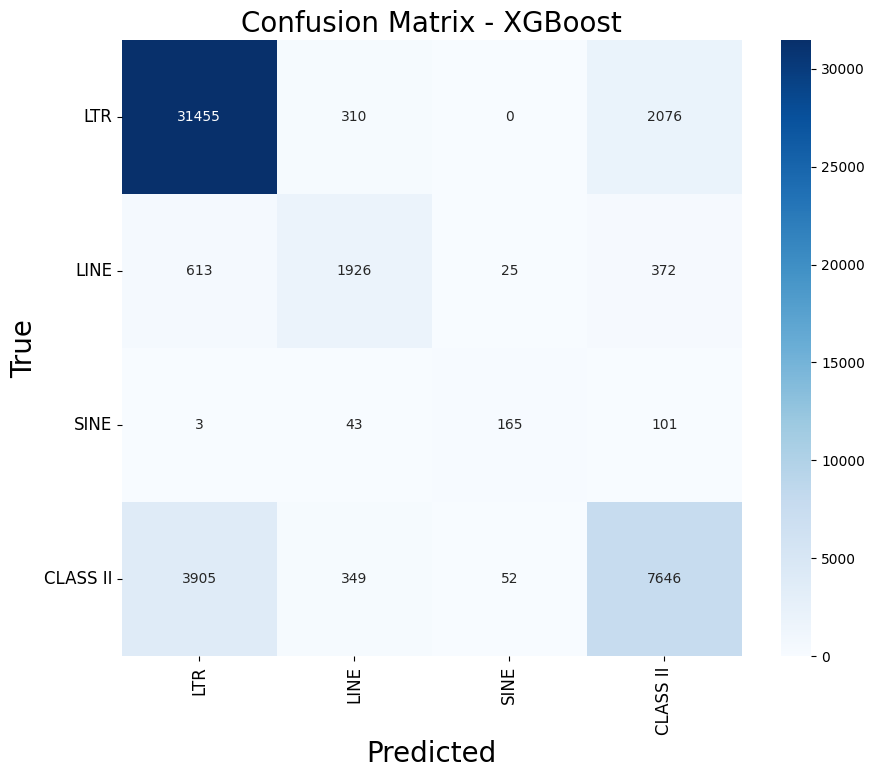

In [ ]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
xgb2 = XGBClassifier(n_estimators=100)
xgb2.fit(feature, labels)

# Cross-validation accuracy
score_xgb2 = cross_val_score(xgb2, feature, labels, cv=10)
res = score_xgb2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(xgb2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(xgb2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
print(cm_xgb2)

cr_xgb2 = classification_report(labels, y_pred_test)
print(cr_xgb2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_xgb2[0, 0] / (cm_xgb2[0, 0] + cm_xgb2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb2[1, 1] / (cm_xgb2[1, 0] + cm_xgb2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_xgb2 = {}
tpr_xgb2 = {}
thresh_xgb2 = {}

n_class = 4
for i in range(n_class):
    fpr_xgb2[i], tpr_xgb2[i], thresh_xgb2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_xgb2 = auc(fpr_xgb2[i], tpr_xgb2[i])
roc_xgb2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_xgb2[i], tpr_xgb2[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-xgb2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
class_names = ['LTR','LINE','SINE','CLASS II']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_xgb2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

plt.savefig('xgb2_cross-val_cm.png')
plt.show()


Mean of Accuracies:  75.0821879993947
[[28250  1290    11  4290]
 [  824  1499    82   531]
 [   14    65   127   106]
 [ 4048   750   213  6941]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     33841
           1       0.42      0.51      0.46      2936
           2       0.29      0.41      0.34       312
           3       0.58      0.58      0.58     11952

    accuracy                           0.75     49041
   macro avg       0.54      0.58      0.56     49041
weighted avg       0.76      0.75      0.75     49041

Accuracy 75.07%
MCC ---> 0.4702985742862812
Sensitivity :  0.9563303994583615
Specificity :  0.6452862677572105


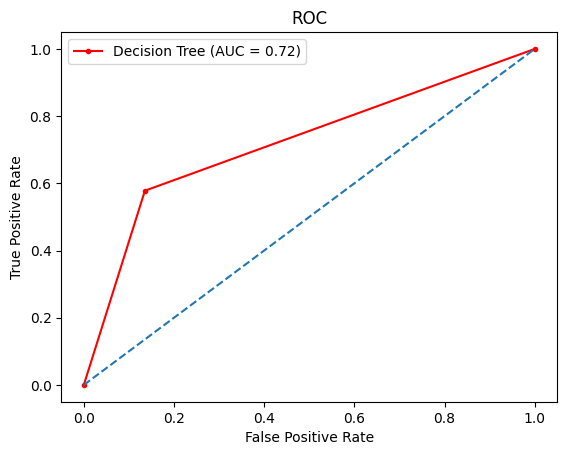

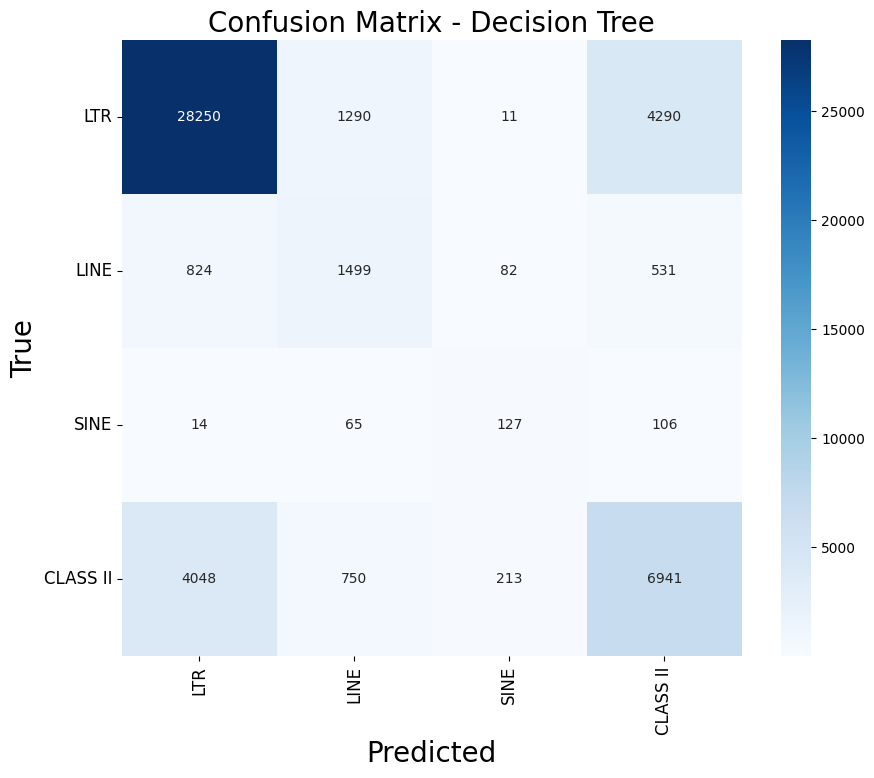

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
dt2 = DecisionTreeClassifier()
dt2.fit(feature, labels)

# Cross-validation accuracy
score_dt2 = cross_val_score(dt2, feature, labels, cv=10)
res = score_dt2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(dt2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(dt2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
print(cm_dt2)

cr_dt2 = classification_report(labels, y_pred_test)
print(cr_dt2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_dt2[0, 0] / (cm_dt2[0, 0] + cm_dt2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt2[1, 1] / (cm_dt2[1, 0] + cm_dt2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_dt2 = {}
tpr_dt2 = {}
thresh_dt2 = {}

n_class = 4
for i in range(n_class):
    fpr_dt2[i], tpr_dt2[i], thresh_dt2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_dt2 = auc(fpr_dt2[i], tpr_dt2[i])
roc_dt2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_dt2[i], tpr_dt2[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-dt2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
class_names = ['LTR','LINE','SINE','CLASS II']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_dt2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

plt.savefig('dt2_cross-val_cm.png')
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.316887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127973
[LightGBM] [Info] Number of data points in the train set: 49041, number of used features: 516
[LightGBM] [Info] Start training from score -0.370984
[LightGBM] [Info] Start training from score -2.815609
[LightGBM] [Info] Start training from score -5.057409
[LightGBM] [Info] Start training from score -1.411758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.284812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127970
[LightGBM] [Info] Number of data points in the train set: 44136, number of used features: 516
[LightGBM] [Info] Start training from score -0.370993
[LightGBM] [Info] Start training from score -2.815361
[LightGBM] [Info] Start training from score -5.056676
[LightGBM] [Info] Start training from 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.283895 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127869
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -0.370983
[LightGBM] [Info] Start training from score -2.815762
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -1.411742


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.280779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127813
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -0.370983
[LightGBM] [Info] Start training from score -2.815762
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -1.411742


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.410470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127912
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -0.370983
[LightGBM] [Info] Start training from score -2.815384
[LightGBM] [Info] Start training from score -5.060264
[LightGBM] [Info] Start training from score -1.411742


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.478106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127800
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -0.370983
[LightGBM] [Info] Start training from score -2.815384
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -1.411835


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[31202   330     4  2305]
 [  640  1870    35   391]
 [    2    52   153   105]
 [ 4214   373    94  7271]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89     33841
           1       0.71      0.64      0.67      2936
           2       0.53      0.49      0.51       312
           3       0.72      0.61      0.66     11952

    accuracy                           0.83     49041
   macro avg       0.71      0.66      0.68     49041
weighted avg       0.82      0.83      0.82     49041

Accuracy 82.58%
MCC ---> 0.6067013538660256
Sensitivity :  0.9895344412025878
Specificity :  0.7450199203187251


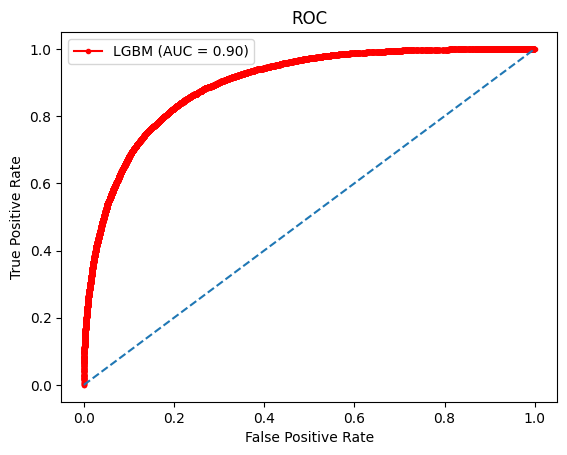

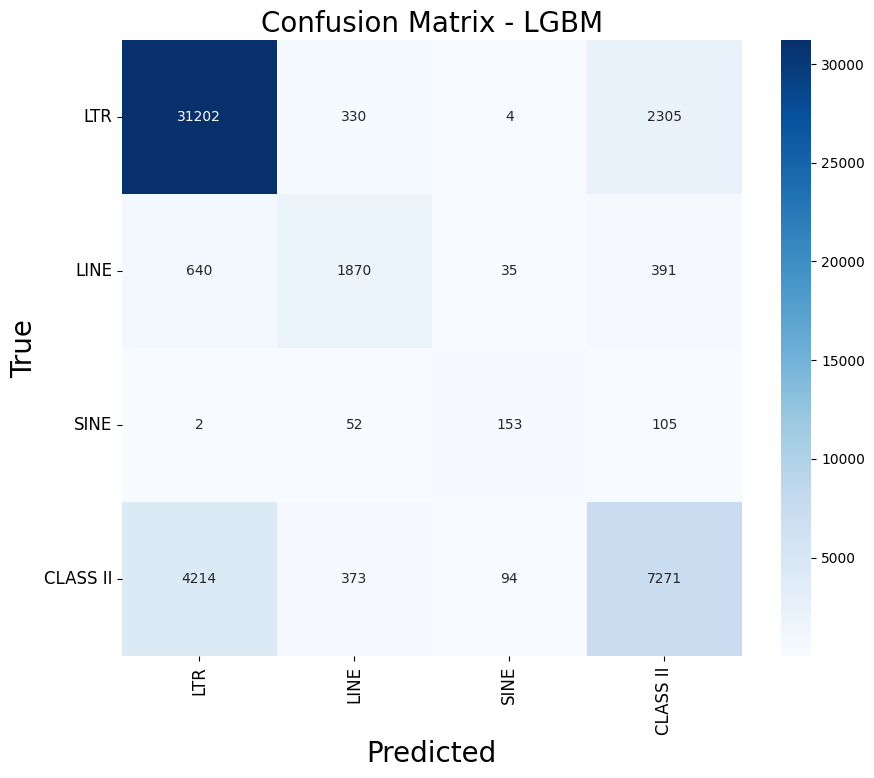

In [ ]:
from lightgbm import LGBMClassifier
lgbm2=LGBMClassifier(
    n_estimators=100
)
lgbm2.fit(feature, labels)

# Cross-validation accuracy
score_lgbm2 = cross_val_score(lgbm2, feature, labels, cv=10)
res = score_lgbm2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(lgbm2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(lgbm2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
print(cm_lgbm2)

cr_lgbm2 = classification_report(labels, y_pred_test)
print(cr_lgbm2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_lgbm2[0, 0] / (cm_lgbm2[0, 0] + cm_lgbm2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm2[1, 1] / (cm_lgbm2[1, 0] + cm_lgbm2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_lgbm2 = {}
tpr_lgbm2 = {}
thresh_lgbm2 = {}

n_class = 4
for i in range(n_class):
    fpr_lgbm2[i], tpr_lgbm2[i], thresh_lgbm2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_lgbm2 = auc(fpr_lgbm2[i], tpr_lgbm2[i])
roc_lgbm2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_lgbm2[i], tpr_lgbm2[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-lgbm2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
class_names = ['LTR','LINE','SINE','CLASS II']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_lgbm2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

plt.savefig('lgbm2_cross-val_cm.png')
plt.show()


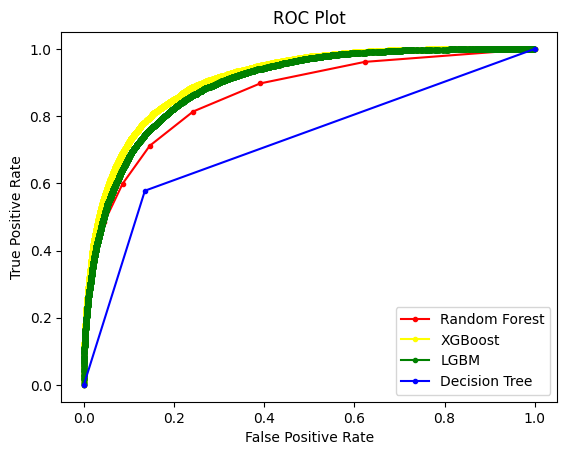

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf2[i],tpr_rf2[i], marker='.',color='red',label = 'Random Forest' % roc_rf2)
plt.plot(fpr_xgb2[i],tpr_xgb2[i], marker='.',color='yellow',label = 'XGBoost' % roc_xgb2)
plt.plot(fpr_lgbm2[i],tpr_lgbm2[i], marker='.',color='green',label = 'LGBM' % roc_lgbm2)
plt.plot(fpr_dt2[i],tpr_dt2[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt2)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('cross-val-roc.png')
# Show plot
plt.show()
